# Week 6: Feature Engineering & Model Optimization
## House Price Prediction

### Objective

The objective of this project is to improve the performance of the house price prediction model developed in previous weeks through feature engineering, feature transformation, feature selection, and hyperparameter optimization.

The House Price Prediction dataset contains information about residential properties, including area, number of bedrooms, bathrooms, stories, parking spaces, location-related features, and furnishing status.

The dataset was initially cleaned during Week 1 by removing duplicate records and handling missing values. The cleaned dataset from Week 5 is used as the starting point for this week's analysis.

### Week 6 Goals

The following tasks will be performed:

1. Create meaningful features from existing variables.
2. Transform categorical and numerical variables into suitable formats for machine learning.
3. Identify and select the most relevant predictive features.
4. Establish a baseline model using the selected features.
5. Optimize the model using hyperparameter tuning and cross-validation.
6. Compare model performance before and after optimization.
7. Identify the most important predictors of house prices.
8. Document the findings and recommendations.

### Evaluation Metrics

Since this is a regression problem, model performance will be evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

## 1. Import Required Libraries

The following Python libraries are used for data manipulation, visualization, preprocessing, feature selection, model development, and hyperparameter optimization.

In [232]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [233]:
housing = pd.read_csv("./../data/cleaned/housing_cleaned.csv")

housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [234]:
housing.shape

(545, 13)

In [235]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [236]:
housing.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [237]:
housing.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### Observation

The dataset contains the cleaned observations prepared during Week 1. The
verification confirms that missing values and duplicate records have already
been addressed.

The dataset contains both numerical and categorical variables. The numerical
variables describe characteristics such as price, area, number of bedrooms,
bathrooms, stories, and parking spaces, while categorical variables describe
features such as road access, guest rooms, basement availability,
air conditioning, preferred area, and furnishing status.

## 5. Identify Numerical and Categorical Features


In [238]:
housing.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

In [239]:
numerical_features = housing.select_dtypes(include=np.number).columns.tolist()
categorical_features = housing.select_dtypes(include="object").columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

Categorical Features:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


# 6. Feature Engineering

Feature engineering involves creating new variables from existing data in
order to provide the machine learning model with more meaningful information.

The original dataset contains useful property characteristics, but some
relationships are not represented explicitly. For example, the number of
bedrooms alone does not describe the size of the property relative to the
number of bedrooms.

Therefore, additional features will be created to capture relationships
between existing variables.

The engineered features will be evaluated later to determine whether they
provide useful predictive information.

### 6.1 Total Rooms

The `bedrooms` and `bathrooms` variables provide separate information about the
layout of a house.

A new `total_rooms` feature combines these variables to provide a simple
measure of the number of major residential rooms represented in the dataset.

**Formula:**

`total_rooms = bedrooms + bathrooms`

In [240]:
housing["total_rooms"] = housing["bedrooms"] + housing["bathrooms"]

housing[["bedrooms", "bathrooms", "total_rooms"]].head()

,bedrooms,bathrooms,total_rooms
0,4,2,6
1,4,4,8
2,3,2,5
3,4,2,6
4,4,1,5


### 6.2 Area per Bedroom

The total area of a property is an important factor in determining its price.
However, the same area may represent different levels of spaciousness
depending on the number of bedrooms.

The `area_per_bedroom` feature measures the available area relative to the
number of bedrooms.

**Formula:**

`area_per_bedroom = area / bedrooms`

A small constant is used in the denominator to avoid division-by-zero errors.

In [241]:
housing["area_per_bedroom"] = (
    housing["area"] / housing["bedrooms"].replace(0, np.nan)
)

housing["area_per_bedroom"] = housing["area_per_bedroom"].fillna(0)

housing[["area", "bedrooms", "area_per_bedroom"]].head()

,area,bedrooms,area_per_bedroom
0,7420,4,1855.0
1,8960,4,2240.0
2,9960,3,3320.0
3,7500,4,1875.0
4,7420,4,1855.0


### 6.3 Bathrooms per Bedroom

The number of bathrooms can indicate the level of comfort and facilities
available in a property.

Rather than considering bathrooms independently, the
`bathrooms_per_bedroom` feature measures the number of bathrooms relative to
the number of bedrooms.

**Formula:**

`bathrooms_per_bedroom = bathrooms / bedrooms`

In [242]:
housing["bathrooms_per_bedroom"] = (
    housing["bathrooms"] / housing["bedrooms"].replace(0, np.nan)
)

housing["bathrooms_per_bedroom"] = housing["bathrooms_per_bedroom"].fillna(0)

housing[["bedrooms", "bathrooms", "bathrooms_per_bedroom"]].head()

,bedrooms,bathrooms,bathrooms_per_bedroom
0,4,2,0.500000
1,4,4,1.000000
2,3,2,0.666667
3,4,2,0.500000
4,4,1,0.250000


### 6.4 Total Amenities

Several variables in the dataset indicate the presence or absence of property
amenities:

- Guestroom
- Basement
- Hot water heating
- Air conditioning
- Main road access
- Preferred area

These variables are currently represented as separate categorical variables.
A new `total_amenities` feature aggregates selected property features to
represent the overall availability of these amenities.

Each available amenity is assigned a value of 1, while its absence is assigned
0.

This feature provides the model with a single measure of the property's
overall amenity availability.

In [243]:
binary_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in binary_columns:
    housing[col + "_binary"] = housing[col].map({"yes": 1, "no": 0})

In [244]:
housing["total_amenities"] = housing[
    [col + "_binary" for col in binary_columns]
].sum(axis=1)

housing[["total_amenities"]].head()

,total_amenities
0,3
1,2
2,3
3,4
4,4


### 6.5 Property Size Category

The `area` variable is continuous. For additional analysis, properties can
also be grouped into size categories.

The categories are based on the distribution of property areas rather than
arbitrary thresholds. Quartiles are used to divide properties into four
groups:

- Small
- Medium
- Large
- Very Large

This provides a categorical representation of property size while preserving
the original continuous `area` variable for the machine learning models.

In [245]:
housing["area_category"] = pd.qcut(
    housing["area"],
    q=4,
    labels=["Small", "Medium", "Large", "Very Large"]
)

housing[["area", "area_category"]].head()

,area,area_category
0,7420,Very Large
1,8960,Very Large
2,9960,Very Large
3,7500,Very Large
4,7420,Very Large


## 7. Review the Engineered Features

After creating the new features, the dataset is inspected to verify that the
features were created correctly and to compare the original variables with
their engineered counterparts.

In [246]:
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,total_rooms,area_per_bedroom,bathrooms_per_bedroom,mainroad_binary,guestroom_binary,basement_binary,hotwaterheating_binary,airconditioning_binary,prefarea_binary,total_amenities,area_category
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,6,1855.0,0.500000,1,0,0,0,1,1,3,Very Large
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,8,2240.0,1.000000,1,0,0,0,1,0,2,Very Large
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,5,3320.0,0.666667,1,0,1,0,0,1,3,Very Large
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,6,1875.0,0.500000,1,0,1,0,1,1,4,Very Large
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,5,1855.0,0.250000,1,1,1,0,1,0,4,Very Large


In [247]:
housing.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus', 'total_rooms',
       'area_per_bedroom', 'bathrooms_per_bedroom', 'mainroad_binary',
       'guestroom_binary', 'basement_binary', 'hotwaterheating_binary',
       'airconditioning_binary', 'prefarea_binary', 'total_amenities',
       'area_category'],
      dtype='str')

In [248]:
housing.describe(include="all")

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,total_rooms,area_per_bedroom,bathrooms_per_bedroom,mainroad_binary,guestroom_binary,basement_binary,hotwaterheating_binary,airconditioning_binary,prefarea_binary,total_amenities,area_category
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545,545,545,545,545,545.000000,545,545,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,semi-furnished,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Small
freq,NaN,NaN,NaN,NaN,NaN,468,448,354,520,373,NaN,417,227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,144
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,NaN,NaN,NaN,NaN,NaN,0.693578,NaN,NaN,4.251376,1819.852599,0.446361,0.858716,0.177982,0.350459,0.045872,0.315596,0.234862,1.983486,NaN
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,NaN,NaN,NaN,NaN,NaN,0.861586,NaN,NaN,1.036611,839.091825,0.159492,0.348635,0.382849,0.477552,0.209399,0.465180,0.424302,1.195004,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,2.000000,381.000000,0.166667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,4.000000,1237.500000,0.333333,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,4.000000,1666.666667,0.400000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,NaN
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,5.000000,2183.333333,0.500000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,NaN


# 8. Feature Relationship Analysis

Before selecting features for modeling, it is useful to examine the
relationships between numerical variables.

Correlation analysis provides an initial indication of how strongly numerical
features are associated with house price.

A correlation close to +1 indicates a strong positive linear relationship,
while a correlation close to -1 indicates a strong negative relationship.
Values close to 0 indicate a weak linear relationship.

Correlation does not imply causation, but it provides useful evidence for
initial feature selection.

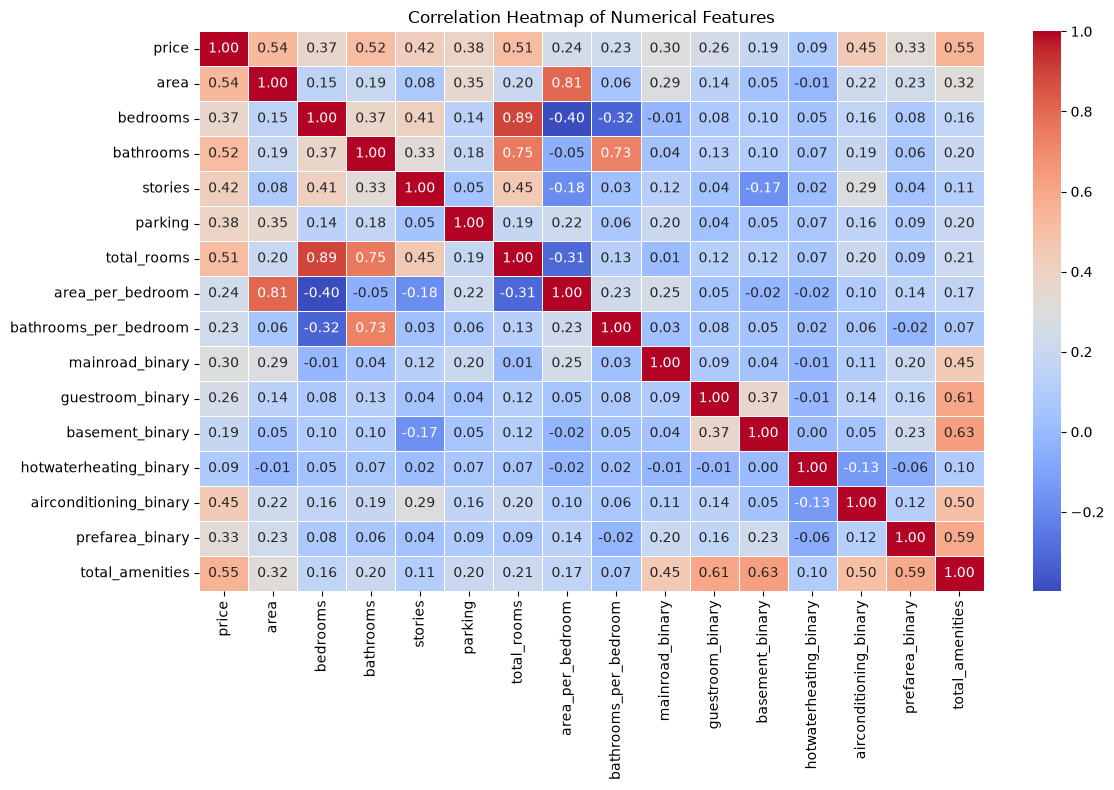

In [249]:
plt.figure(figsize=(12, 8))

numeric_data = housing.select_dtypes(include=np.number)

correlation_matrix = numeric_data.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [250]:
price_correlation = (
    correlation_matrix["price"]
    .sort_values(ascending=False)
)

price_correlation

price                     1.000000
total_amenities           0.552954
area                      0.535997
bathrooms                 0.517545
total_rooms               0.511809
airconditioning_binary    0.452954
stories                   0.420712
parking                   0.384394
bedrooms                  0.366494
prefarea_binary           0.329777
mainroad_binary           0.296898
guestroom_binary          0.255517
area_per_bedroom          0.244809
bathrooms_per_bedroom     0.231732
basement_binary           0.187057
hotwaterheating_binary    0.093073
Name: price, dtype: float64

# 9. Data Preparation for Modeling

The target variable is `price`, while all remaining variables are considered
potential predictors.

The dataset contains both numerical and categorical variables. Numerical
variables will be standardized using `StandardScaler`, while categorical
variables will be converted into numerical representations using
one-hot encoding.

A `ColumnTransformer` will be used to apply the appropriate transformation
to each feature type.

Using a preprocessing pipeline is important because the transformations are
learned only from the training data, helping prevent data leakage.

In [251]:
X = housing.drop("price", axis=1)
y = housing["price"]

In [252]:
binary_helper_columns = [col + "_binary" for col in binary_columns]

X = X.drop(columns=binary_helper_columns)

In [253]:
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'total_rooms', 'area_per_bedroom', 'bathrooms_per_bedroom', 'total_amenities']

Categorical Features:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


## 10. Train-Test Split

The dataset is divided into training and testing sets.

The training set is used to learn patterns and optimize the model, while the
testing set is kept separate and is used only for final performance
evaluation.

A test size of 20% is used, leaving 80% of the observations for training.

`random_state=42` is used to ensure that the same observations are selected
each time the notebook is executed.

In [254]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (436, 17)
Testing set: (109, 17)


# 11. Feature Transformation

The predictors contain both numerical and categorical variables, so different
transformations are required.

### Numerical features

Numerical variables are standardized using `StandardScaler`. Standardization
transforms the variables so that they have approximately zero mean and unit
variance.

### Categorical features

Categorical variables are transformed using `OneHotEncoder`. This creates
binary indicator variables for the different categories without introducing
an artificial numerical ordering.

The transformations are combined using `ColumnTransformer`.

In [255]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features
        )
    ]
)

# 12. Baseline Gradient Boosting Model

In Week 5, several regression algorithms were evaluated. Gradient Boosting
achieved the strongest performance among the tested models, with:

- MAE: **961,734.63**
- R²: **0.6650**

Therefore, Gradient Boosting Regressor is selected as the primary model for
Week 6 optimization.

The baseline model will first be trained using the engineered and transformed
features with default model hyperparameters. Its performance will then be
compared against the optimized model.

In [256]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ]
)

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['area','bedrooms','bathrooms',...,'bathrooms_per_bedroom', 'total_amenities','area_category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through.

In [257]:
y_pred_baseline = baseline_model.predict(X_test)

baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2 = r2_score(y_test, y_pred_baseline)

print("Baseline Gradient Boosting Performance")
print("-" * 45)
print(f"MAE:  {baseline_mae:,.2f}")
print(f"RMSE: {baseline_rmse:,.2f}")
print(f"R²:   {baseline_r2:.4f}")

Baseline Gradient Boosting Performance
---------------------------------------------
MAE:  1,021,294.42
RMSE: 1,448,480.60
R²:   0.5849


# 14. Cross-Validation

A single train-test split provides only one estimate of model performance.
Cross-validation provides a more robust estimate by repeatedly training and
evaluating the model on different subsets of the training data.

Five-fold cross-validation is used in this project.

The training data is divided into five folds. The model is trained on four
folds and validated on the remaining fold. This process is repeated until
each fold has been used as the validation set.

The resulting scores provide an indication of how consistently the model
performs across different subsets of the data.

In [ ]:
cv_scores = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross-Validation R² Scores:")
print(cv_scores)

print(f"\nMean CV R²: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")